# EDA Parte 2 - Análise Exploratória das Variáveis Transformadas

Este notebook apresenta uma análise exploratória detalhada das variáveis após aplicação das transformações Yeo-Johnson identificadas no notebook `07_transformacoes.ipynb`.

## Objetivos:
1. Aplicar as transformações Yeo-Johnson nas variáveis
2. Comparar distribuições antes e depois das transformações
3. Avaliar melhoria na normalidade e simetria
4. Verificar impacto no poder discriminativo
5. Análise estatística completa das variáveis transformadas

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu
from sklearn.preprocessing import PowerTransformer

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados

In [2]:
# Carregar dataset de treino
df_treino = pd.read_csv('../data/processed/df_treino.csv')

# Carregar resultados das melhores transformações
best_transformations = pd.read_csv('../data/processed/best_transformations.csv')

print(f"✓ Dataset de treino carregado: {df_treino.shape}")
print(f"✓ Melhores transformações carregadas: {best_transformations.shape}")
print("\n" + "="*80)
print("MELHORES TRANSFORMAÇÕES IDENTIFICADAS:")
print("="*80)
print(best_transformations[['variable', 'transformation']].to_string(index=False))

✓ Dataset de treino carregado: (25001186, 21)
✓ Melhores transformações carregadas: (6, 11)

MELHORES TRANSFORMAÇÕES IDENTIFICADAS:
       variable transformation
    Amount Paid     yeojohnson
Amount Received     yeojohnson
        Bank ID     yeojohnson
     Bank ID_To     yeojohnson
      From Bank     yeojohnson
        To Bank     yeojohnson


## 3. Aplicação das Transformações Yeo-Johnson

In [3]:
# Variáveis a serem transformadas
feature_cols = ['From Bank', 'To Bank', 'Amount Received', 'Amount Paid', 'Bank ID', 'Bank ID_To']
target_col = 'Is Laundering'

# Criar DataFrame com dados originais
df_original = df_treino[feature_cols].copy()

# Criar DataFrame para dados transformados
df_transformed = pd.DataFrame()

# Aplicar transformação Yeo-Johnson em cada variável
print("Aplicando transformações Yeo-Johnson...")
print("="*80)

for col in feature_cols:
    print(f"Transformando: {col}")
    
    # Preparar dados (remover NaN e infinitos)
    data = df_treino[col].copy()
    valid_mask = ~(np.isnan(data) | np.isinf(data))
    
    # Aplicar transformação
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    transformed = data.copy()
    transformed[valid_mask] = pt.fit_transform(data[valid_mask].values.reshape(-1, 1)).flatten()
    
    df_transformed[col] = transformed

print("\n✓ Transformações aplicadas com sucesso!")
print(f"Shape original: {df_original.shape}")
print(f"Shape transformado: {df_transformed.shape}")

Aplicando transformações Yeo-Johnson...
Transformando: From Bank
Transformando: To Bank
Transformando: Amount Received
Transformando: Amount Paid
Transformando: Bank ID
Transformando: Bank ID_To

✓ Transformações aplicadas com sucesso!
Shape original: (25001186, 6)
Shape transformado: (25001186, 6)


## 4. Estatísticas Descritivas - Comparação Antes e Depois

In [4]:
print("="*80)
print("ESTATÍSTICAS DESCRITIVAS - DADOS ORIGINAIS")
print("="*80)
display(df_original.describe().T)

print("\n" + "="*80)
print("ESTATÍSTICAS DESCRITIVAS - DADOS TRANSFORMADOS")
print("="*80)
display(df_transformed.describe().T)

ESTATÍSTICAS DESCRITIVAS - DADOS ORIGINAIS


,count,mean,std,min,25%,50%,75%,max
From Bank,25001186.0,2.754776e+05,5.900833e+05,0.000000,2695.00,44763.00,211537.00,3.219766e+06
To Bank,25001186.0,3.925188e+05,6.377676e+05,0.000000,28596.00,143136.00,249693.00,3.219766e+06
Amount Received,25001186.0,7.865921e+06,1.790779e+09,0.000001,194.98,1416.71,11867.05,2.020628e+12
Amount Paid,25001186.0,5.318006e+06,1.309452e+09,0.000001,196.28,1419.77,11789.96,2.020628e+12
Bank ID,25001186.0,2.754776e+05,5.900833e+05,0.000000,2695.00,44763.00,211537.00,3.219766e+06
Bank ID_To,25001186.0,3.925188e+05,6.377676e+05,0.000000,28596.00,143136.00,249693.00,3.219766e+06



ESTATÍSTICAS DESCRITIVAS - DADOS TRANSFORMADOS


,count,mean,std,min,25%,50%,75%,max
From Bank,25001186.0,21.116621,10.412189,0.000000e+00,13.242042,21.961174,28.217966,42.474836
To Bank,25001186.0,40.122922,15.913810,0.000000e+00,29.270076,40.848900,45.685512,75.244506
Amount Received,25001186.0,6.371034,2.470695,9.999995e-07,4.799382,6.372789,7.940091,17.634178
Amount Paid,25001186.0,6.395076,2.478043,9.999995e-07,4.816868,6.396118,7.969872,17.838715
Bank ID,25001186.0,21.116621,10.412189,0.000000e+00,13.242042,21.961174,28.217966,42.474836
Bank ID_To,25001186.0,40.122922,15.913810,0.000000e+00,29.270076,40.848900,45.685512,75.244506


## 5. Análise de Normalidade - Antes e Depois

In [5]:
# Testar normalidade com Shapiro-Wilk (amostra de 5000)
print("="*80)
print("TESTE DE NORMALIDADE - SHAPIRO-WILK")
print("="*80)

normality_results = []

for col in feature_cols:
    # Amostra para teste
    sample_size = 5000
    
    # Original
    sample_orig = df_original[col].dropna().sample(n=sample_size, random_state=42)
    stat_orig, p_orig = shapiro(sample_orig)
    
    # Transformado
    sample_trans = df_transformed[col].dropna().sample(n=sample_size, random_state=42)
    stat_trans, p_trans = shapiro(sample_trans)
    
    # Skewness e Kurtosis
    skew_orig = stats.skew(df_original[col].dropna())
    skew_trans = stats.skew(df_transformed[col].dropna())
    
    kurt_orig = stats.kurtosis(df_original[col].dropna())
    kurt_trans = stats.kurtosis(df_transformed[col].dropna())
    
    normality_results.append({
        'Variável': col,
        'Shapiro_p_Original': p_orig,
        'Shapiro_p_Transformado': p_trans,
        'Skewness_Original': skew_orig,
        'Skewness_Transformado': skew_trans,
        'Kurtosis_Original': kurt_orig,
        'Kurtosis_Transformado': kurt_trans
    })

df_normality = pd.DataFrame(normality_results)
display(df_normality)

TESTE DE NORMALIDADE - SHAPIRO-WILK


,Variável,Shapiro_p_Original,Shapiro_p_Transformado,Skewness_Original,Skewness_Transformado,Kurtosis_Original,Kurtosis_Transformado
0,From Bank,9.849052e-81,1.334216e-35,3.019323,-0.127102,8.780925,-0.728572
1,To Bank,2.439459e-75,3.642955e-36,2.061614,-0.021644,3.059869,-0.034321
2,Amount Received,2.381059e-95,1.057689e-10,590.970876,-0.008733,424778.606649,0.219275
3,Amount Paid,2.011222e-95,1.412993e-10,790.773487,-0.008369,768326.650230,0.217127
4,Bank ID,9.849052e-81,1.334216e-35,3.019323,-0.127102,8.780925,-0.728572
5,Bank ID_To,2.439459e-75,3.642955e-36,2.061614,-0.021644,3.059869,-0.034321


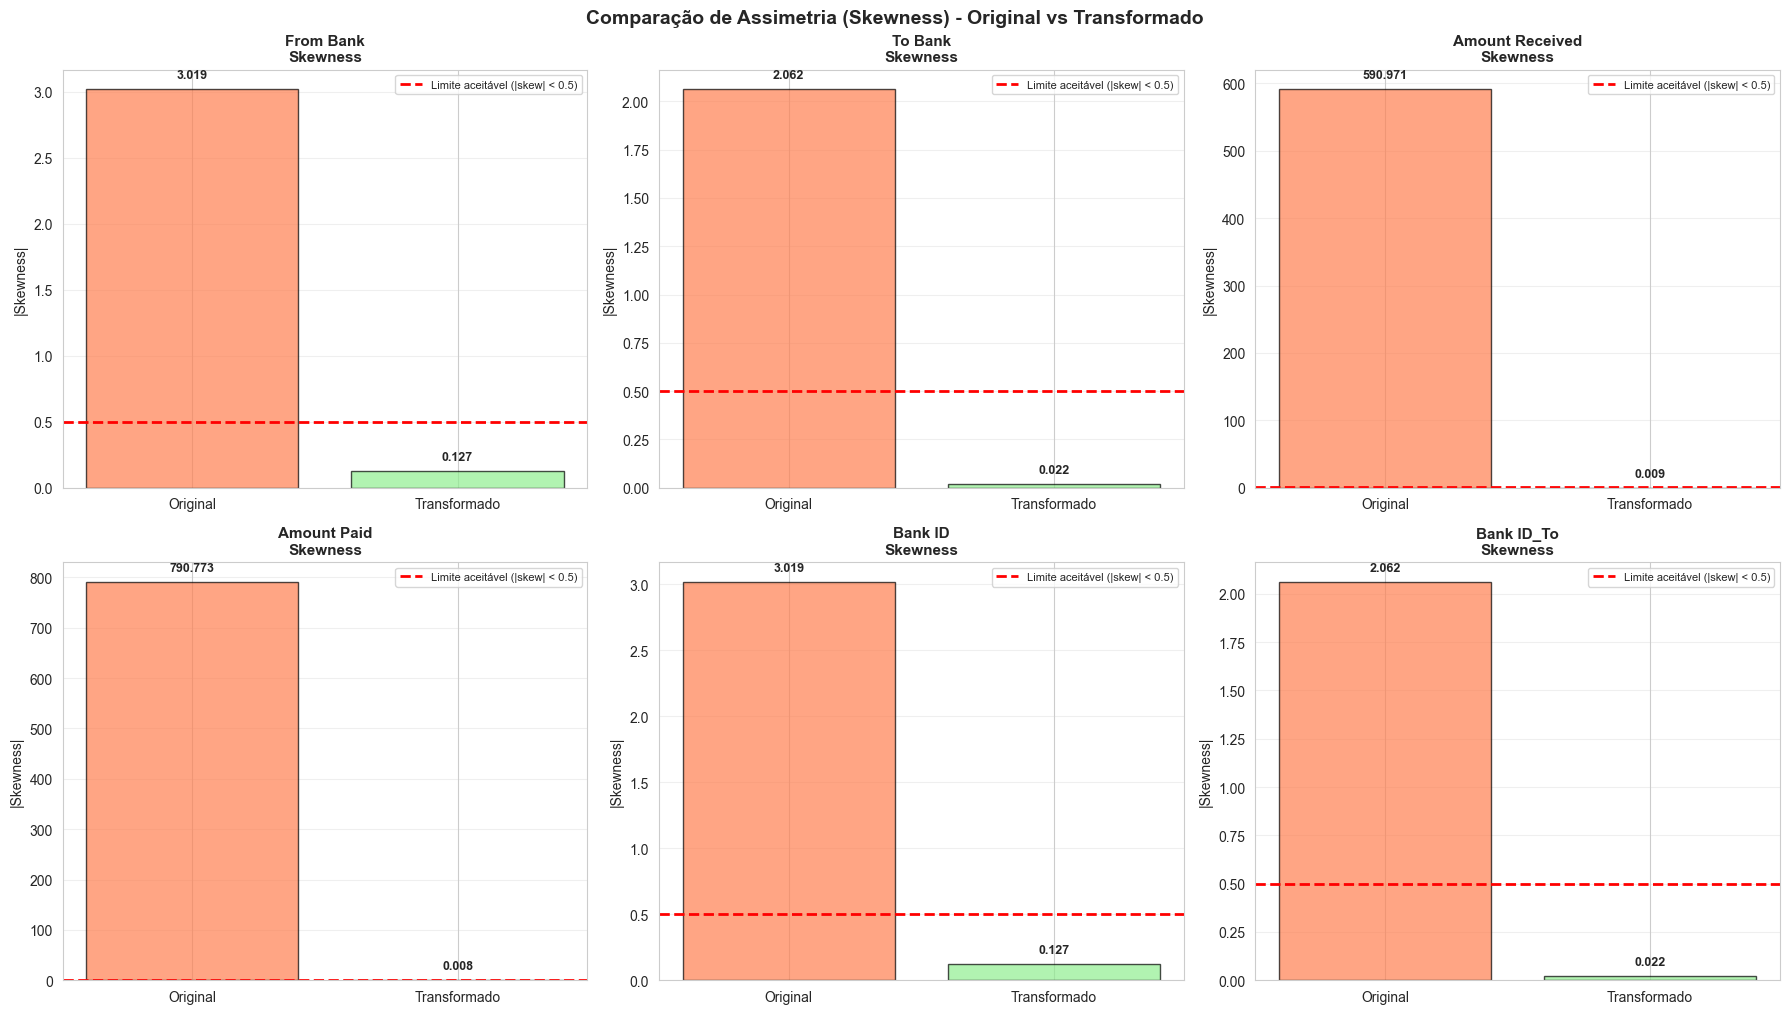

In [6]:
# Visualização da melhoria na normalidade
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    ax = axes[idx]
    
    # Valores de skewness
    skew_orig = df_normality[df_normality['Variável'] == col]['Skewness_Original'].values[0]
    skew_trans = df_normality[df_normality['Variável'] == col]['Skewness_Transformado'].values[0]
    
    x = ['Original', 'Transformado']
    y = [abs(skew_orig), abs(skew_trans)]
    colors = ['coral', 'lightgreen']
    
    ax.bar(x, y, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Limite aceitável (|skew| < 0.5)')
    ax.set_title(f'{col}\nSkewness', fontsize=11, fontweight='bold')
    ax.set_ylabel('|Skewness|')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    # Adicionar valores nas barras
    for i, v in enumerate(y):
        ax.text(i, v + max(y)*0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.suptitle('Comparação de Assimetria (Skewness) - Original vs Transformado', 
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

## 6. Comparação Visual das Distribuições

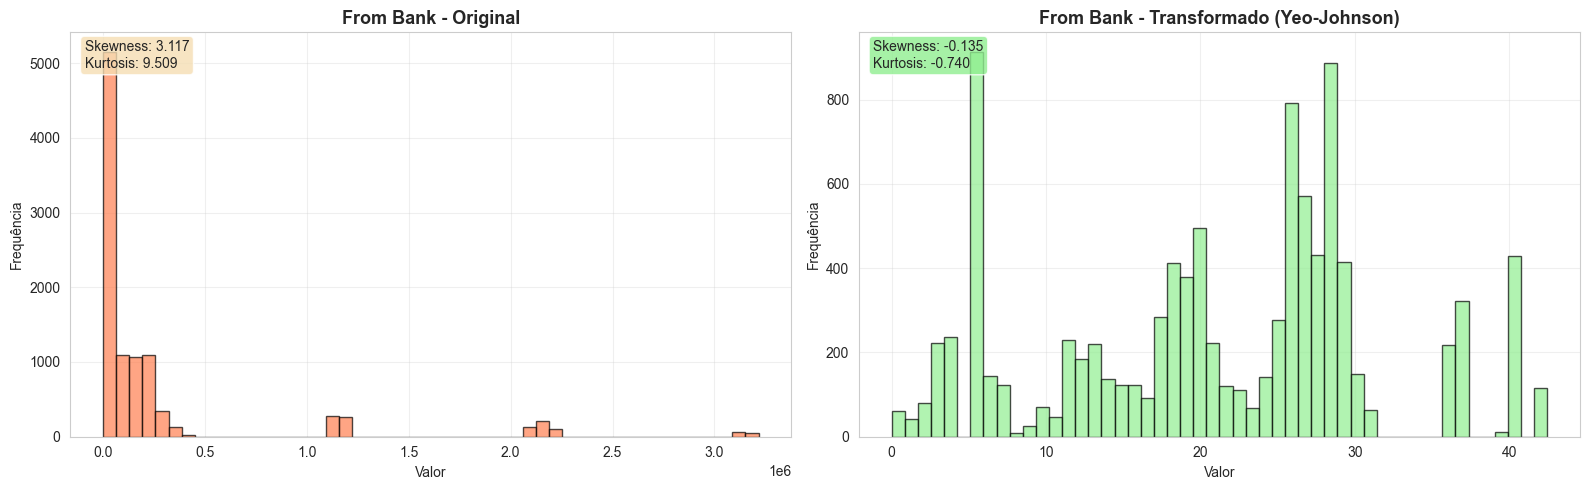

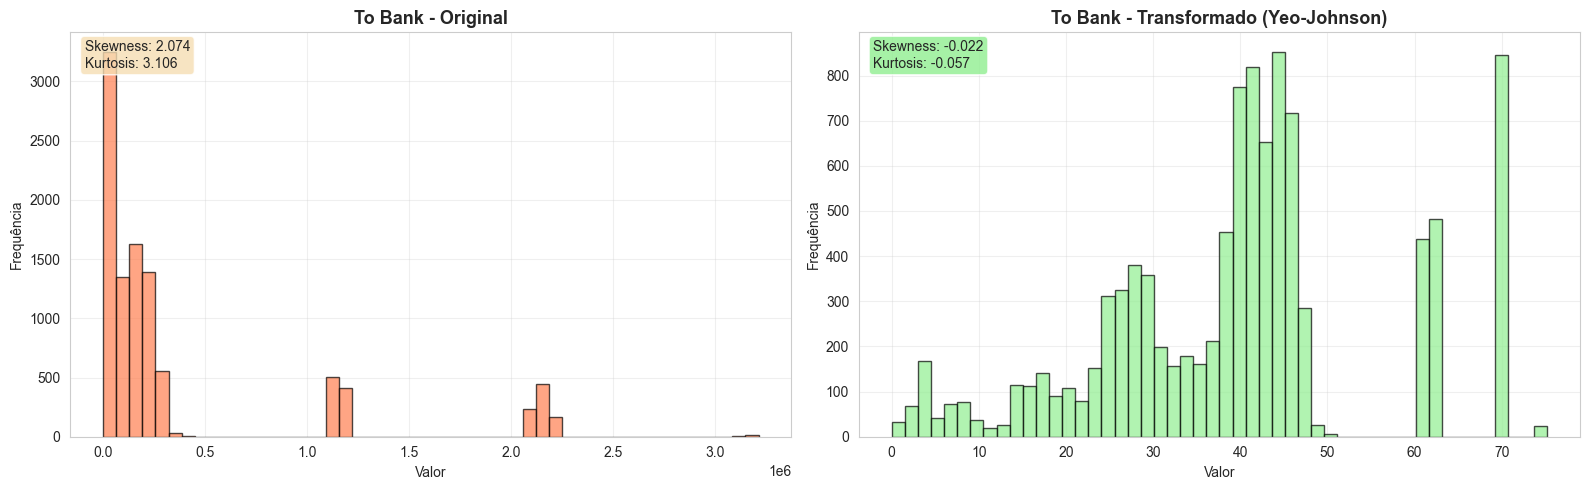

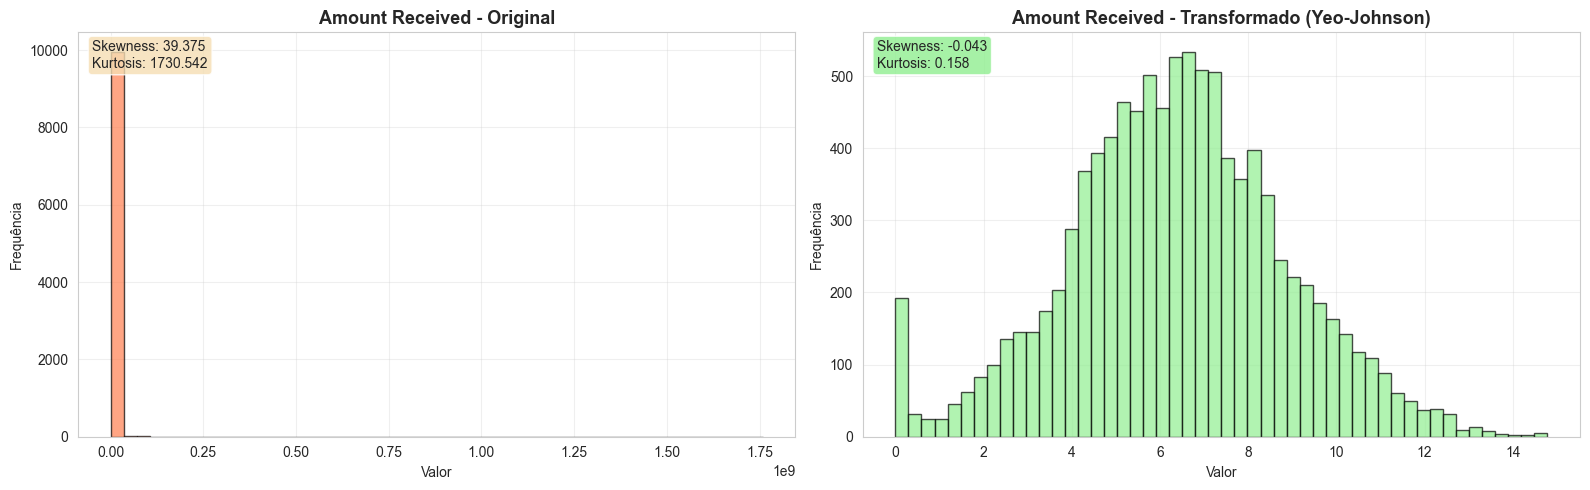

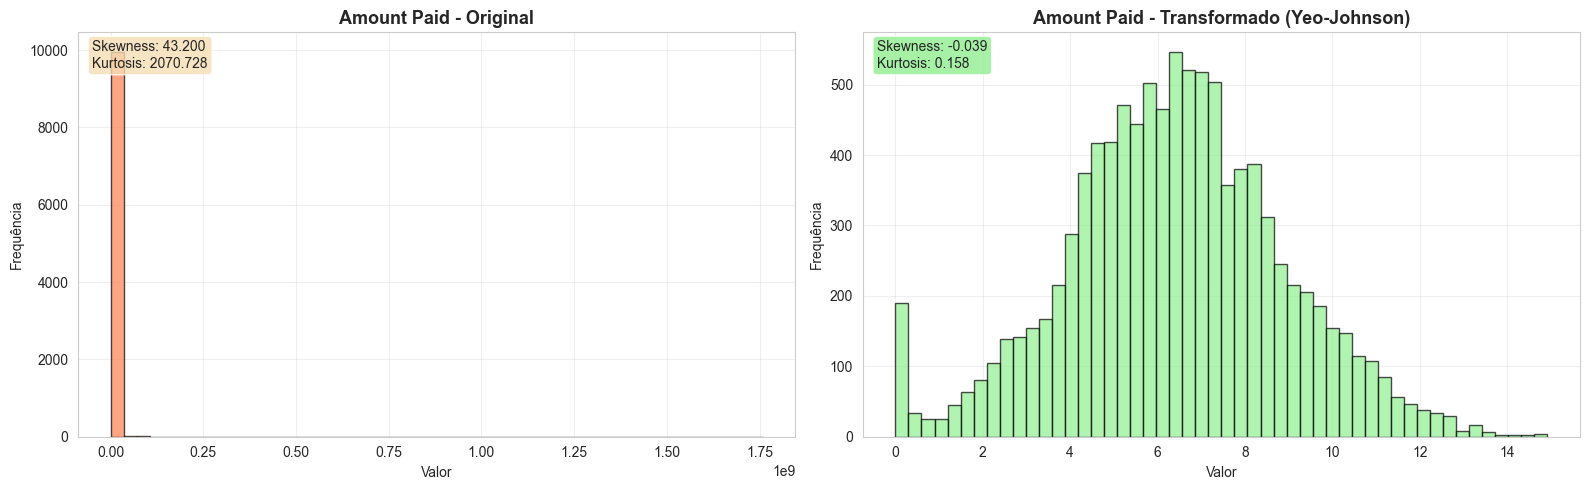

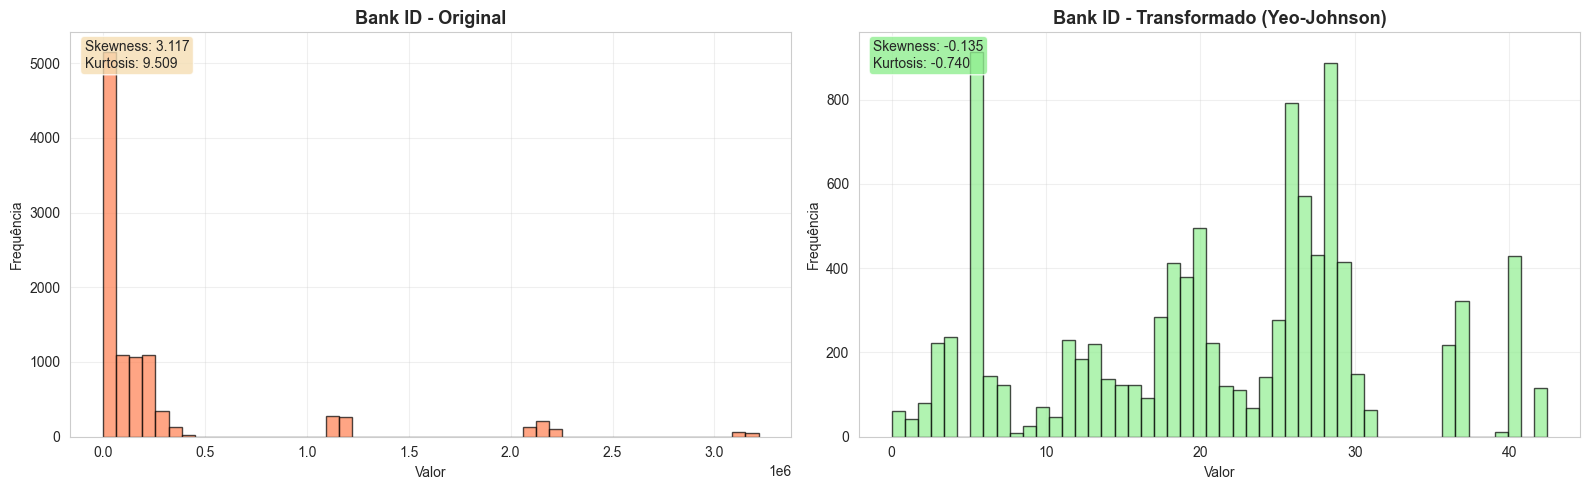

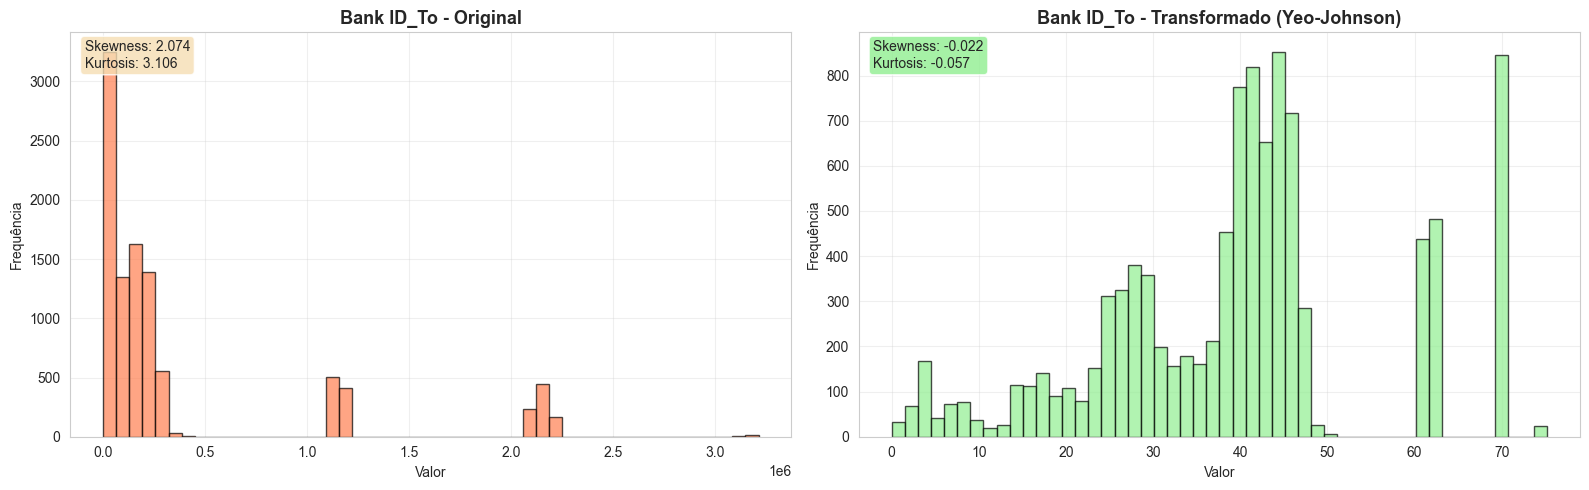

In [11]:
# Comparação das distribuições - Histogramas lado a lado
for col in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Amostra para visualização
    sample_size = 10000
    sample_orig = df_original[col].dropna().sample(n=sample_size, random_state=42)
    sample_trans = df_transformed[col].dropna().sample(n=sample_size, random_state=42)
    
    # Original
    axes[0].hist(sample_orig, bins=50, color='coral', alpha=0.7, edgecolor='black')
    axes[0].set_title(f'{col} - Original', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Valor')
    axes[0].set_ylabel('Frequência')
    axes[0].grid(True, alpha=0.3)
    
    # Adicionar estatísticas
    skew_orig = stats.skew(sample_orig)
    kurt_orig = stats.kurtosis(sample_orig)
    axes[0].text(0.02, 0.98, f'Skewness: {skew_orig:.3f}\nKurtosis: {kurt_orig:.3f}',
                transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Transformado
    axes[1].hist(sample_trans, bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
    axes[1].set_title(f'{col} - Transformado (Yeo-Johnson)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Valor')
    axes[1].set_ylabel('Frequência')
    axes[1].grid(True, alpha=0.3)
    
    # Adicionar estatísticas
    skew_trans = stats.skew(sample_trans)
    kurt_trans = stats.kurtosis(sample_trans)
    axes[1].text(0.02, 0.98, f'Skewness: {skew_trans:.3f}\nKurtosis: {kurt_trans:.3f}',
                transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

## 7. Q-Q Plots - Verificação de Normalidade Visual

In [ ]:
# Q-Q plots comparativos
for col in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Amostra para Q-Q plot
    sample_size = 5000
    sample_orig = df_original[col].dropna().sample(n=sample_size, random_state=42)
    sample_trans = df_transformed[col].dropna().sample(n=sample_size, random_state=42)
    
    # Q-Q plot original
    stats.probplot(sample_orig, dist="norm", plot=axes[0])
    axes[0].set_title(f'Q-Q Plot: {col} - Original', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Q-Q plot transformado
    stats.probplot(sample_trans, dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot: {col} - Transformado', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. Boxplots - Análise de Outliers

In [ ]:
# Boxplots comparativos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    ax = axes[idx]
    
    # Amostra para boxplot
    sample_size = 10000
    sample_orig = df_original[col].dropna().sample(n=sample_size, random_state=42)
    sample_trans = df_transformed[col].dropna().sample(n=sample_size, random_state=42)
    
    # Criar boxplots lado a lado
    bp = ax.boxplot([sample_orig, sample_trans], 
                     labels=['Original', 'Transformado'],
                     patch_artist=True,
                     widths=0.6)
    
    # Cores
    bp['boxes'][0].set_facecolor('coral')
    bp['boxes'][1].set_facecolor('lightgreen')
    
    for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
        plt.setp(bp[element], color='black')
    
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('Comparação de Outliers - Original vs Transformado', 
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

## 9. Poder Discriminativo - Comparação por Grupo (Is Laundering)

In [7]:
# Análise discriminativa - Mann-Whitney U test
print("="*80)
print("PODER DISCRIMINATIVO - TESTE MANN-WHITNEY U")
print("="*80)

discrimination_results = []
target = df_treino[target_col]

for col in feature_cols:
    # Separar por grupo
    group_0_orig = df_original[col][target == 0].dropna()
    group_1_orig = df_original[col][target == 1].dropna()
    
    group_0_trans = df_transformed[col][target == 0].dropna()
    group_1_trans = df_transformed[col][target == 1].dropna()
    
    # Amostra para teste
    sample_size = 5000
    g0_orig_sample = group_0_orig.sample(n=min(sample_size, len(group_0_orig)), random_state=42)
    g1_orig_sample = group_1_orig.sample(n=min(sample_size, len(group_1_orig)), random_state=42)
    
    g0_trans_sample = group_0_trans.sample(n=min(sample_size, len(group_0_trans)), random_state=42)
    g1_trans_sample = group_1_trans.sample(n=min(sample_size, len(group_1_trans)), random_state=42)
    
    # Mann-Whitney U test
    stat_orig, p_orig = mannwhitneyu(g0_orig_sample, g1_orig_sample, alternative='two-sided')
    stat_trans, p_trans = mannwhitneyu(g0_trans_sample, g1_trans_sample, alternative='two-sided')
    
    # Medianas
    med_0_orig = group_0_orig.median()
    med_1_orig = group_1_orig.median()
    med_0_trans = group_0_trans.median()
    med_1_trans = group_1_trans.median()
    
    # Diferença percentual
    diff_pct_orig = abs((med_1_orig - med_0_orig) / med_0_orig * 100)
    diff_pct_trans = abs((med_1_trans - med_0_trans) / med_0_trans * 100)
    
    discrimination_results.append({
        'Variável': col,
        'Mann-Whitney_p_Original': p_orig,
        'Mann-Whitney_p_Transformado': p_trans,
        'Mediana_Grupo0_Original': med_0_orig,
        'Mediana_Grupo1_Original': med_1_orig,
        'Diferença_%_Original': diff_pct_orig,
        'Mediana_Grupo0_Transformado': med_0_trans,
        'Mediana_Grupo1_Transformado': med_1_trans,
        'Diferença_%_Transformado': diff_pct_trans
    })

df_discrimination = pd.DataFrame(discrimination_results)
display(df_discrimination)

PODER DISCRIMINATIVO - TESTE MANN-WHITNEY U


,Variável,Mann-Whitney_p_Original,Mann-Whitney_p_Transformado,Mediana_Grupo0_Original,Mediana_Grupo1_Original,Diferença_%_Original,Mediana_Grupo0_Transformado,Mediana_Grupo1_Transformado,Diferença_%_Transformado
0,From Bank,8.105012e-18,8.105012e-18,44763.00,27343.000,38.916069,21.961174,20.209205,7.977576
1,To Bank,6.881724e-12,6.881724e-12,143136.00,124843.000,12.780153,40.848900,39.731875,2.734531
2,Amount Received,5.386952e-104,5.386952e-104,1415.43,3921.315,177.040546,6.372097,7.138641,12.029697
3,Amount Paid,1.486588e-103,1.486588e-103,1418.48,3921.315,176.444856,6.395417,7.166141,12.051196
4,Bank ID,8.105012e-18,8.105012e-18,44763.00,27343.000,38.916069,21.961174,20.209205,7.977576
5,Bank ID_To,6.881724e-12,6.881724e-12,143136.00,124843.000,12.780153,40.848900,39.731875,2.734531


## 10. Matriz de Correlação - Dados Transformados

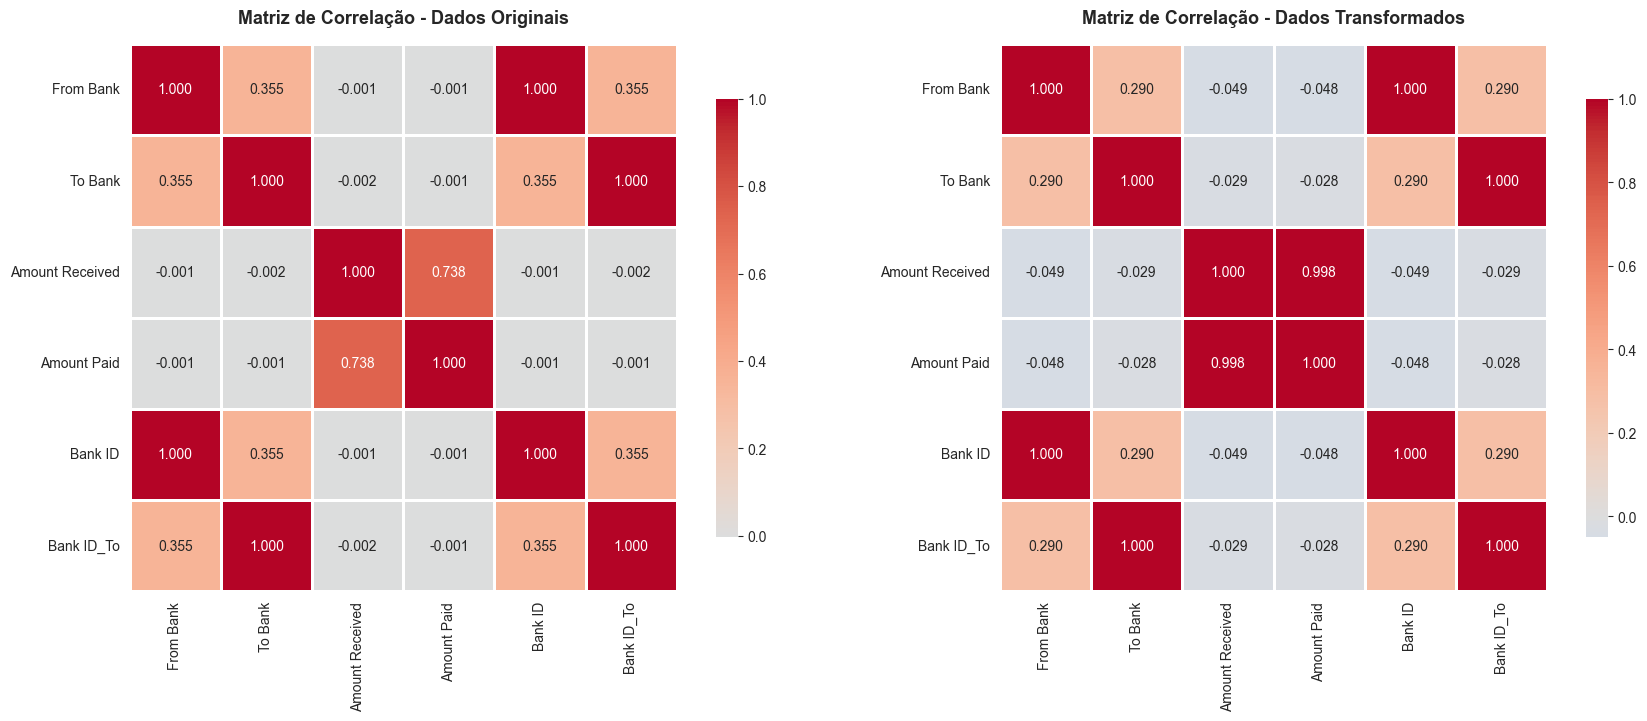


MUDANÇAS NAS CORRELAÇÕES
Maiores mudanças absolutas nas correlações:
  Amount Paid <-> Amount Received: Δ = 0.2597
  Bank ID <-> To Bank: Δ = 0.0651
  To Bank <-> From Bank: Δ = 0.0651
  Bank ID_To <-> From Bank: Δ = 0.0651
  Bank ID_To <-> Bank ID: Δ = 0.0651
  Amount Received <-> From Bank: Δ = 0.0473
  Bank ID <-> Amount Received: Δ = 0.0473
  Amount Paid <-> From Bank: Δ = 0.0471
  Bank ID <-> Amount Paid: Δ = 0.0471
  Amount Received <-> To Bank: Δ = 0.0268


In [8]:
# Matriz de correlação
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Correlação - Original
corr_orig = df_original.corr()
sns.heatmap(corr_orig, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title('Matriz de Correlação - Dados Originais', fontsize=13, fontweight='bold', pad=15)

# Correlação - Transformado
corr_trans = df_transformed.corr()
sns.heatmap(corr_trans, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title('Matriz de Correlação - Dados Transformados', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Diferenças nas correlações
print("\n" + "="*80)
print("MUDANÇAS NAS CORRELAÇÕES")
print("="*80)
corr_diff = (corr_trans - corr_orig).abs()
print("Maiores mudanças absolutas nas correlações:")
# Pegar triângulo superior sem diagonal
mask = np.triu(np.ones_like(corr_diff, dtype=bool), k=1)
corr_diff_masked = corr_diff.where(mask)
top_changes = corr_diff_masked.unstack().sort_values(ascending=False).head(10)
for (var1, var2), diff in top_changes.items():
    if not pd.isna(diff):
        print(f"  {var1} <-> {var2}: Δ = {diff:.4f}")

## 11. Distribuições por Classe (Laundering vs Não Laundering)

In [ ]:
# Distribuições por classe - Variáveis Transformadas
for col in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Preparar dados
    sample_size = 10000
    df_sample = df_treino[[col, target_col]].sample(n=sample_size, random_state=42).copy()
    
    # Aplicar transformação na amostra
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    df_sample['transformed'] = pt.fit_transform(df_sample[[col]])
    
    # Separar por classe
    group_0_orig = df_sample[df_sample[target_col] == 0][col]
    group_1_orig = df_sample[df_sample[target_col] == 1][col]
    
    group_0_trans = df_sample[df_sample[target_col] == 0]['transformed']
    group_1_trans = df_sample[df_sample[target_col] == 1]['transformed']
    
    # Plot Original
    axes[0].hist(group_0_orig, bins=50, alpha=0.6, label='Não Laundering', color='blue', edgecolor='black')
    axes[0].hist(group_1_orig, bins=50, alpha=0.6, label='Laundering', color='red', edgecolor='black')
    axes[0].set_title(f'{col} - Original', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Valor')
    axes[0].set_ylabel('Frequência')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot Transformado
    axes[1].hist(group_0_trans, bins=50, alpha=0.6, label='Não Laundering', color='blue', edgecolor='black')
    axes[1].hist(group_1_trans, bins=50, alpha=0.6, label='Laundering', color='red', edgecolor='black')
    axes[1].set_title(f'{col} - Transformado', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Valor')
    axes[1].set_ylabel('Frequência')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 12. Resumo Final e Conclusões

In [9]:
print("="*80)
print("RESUMO EXECUTIVO - TRANSFORMAÇÕES YEO-JOHNSON")
print("="*80)

summary_data = []

for col in feature_cols:
    # Buscar métricas
    norm_row = df_normality[df_normality['Variável'] == col].iloc[0]
    disc_row = df_discrimination[df_discrimination['Variável'] == col].iloc[0]
    
    # Calcular melhorias
    skew_improvement = ((abs(norm_row['Skewness_Original']) - abs(norm_row['Skewness_Transformado'])) / 
                        abs(norm_row['Skewness_Original']) * 100)
    
    kurt_improvement = ((abs(norm_row['Kurtosis_Original']) - abs(norm_row['Kurtosis_Transformado'])) / 
                        abs(norm_row['Kurtosis_Original']) * 100) if norm_row['Kurtosis_Original'] != 0 else 0
    
    summary_data.append({
        'Variável': col,
        'Skewness_Original': norm_row['Skewness_Original'],
        'Skewness_Transformado': norm_row['Skewness_Transformado'],
        'Melhoria_Skewness_%': skew_improvement,
        'Kurtosis_Original': norm_row['Kurtosis_Original'],
        'Kurtosis_Transformado': norm_row['Kurtosis_Transformado'],
        'Melhoria_Kurtosis_%': kurt_improvement,
        'Mann-Whitney_p_Trans': disc_row['Mann-Whitney_p_Transformado'],
        'Discriminação_Mantida': 'SIM' if disc_row['Mann-Whitney_p_Transformado'] < 0.05 else 'NÃO'
    })

df_summary = pd.DataFrame(summary_data)

print("\n1. MELHORIA NA NORMALIDADE:")
print("-" * 80)
display(df_summary[['Variável', 'Skewness_Original', 'Skewness_Transformado', 
                     'Melhoria_Skewness_%', 'Kurtosis_Original', 'Kurtosis_Transformado',
                     'Melhoria_Kurtosis_%']])

print("\n2. MANUTENÇÃO DO PODER DISCRIMINATIVO:")
print("-" * 80)
display(df_summary[['Variável', 'Mann-Whitney_p_Trans', 'Discriminação_Mantida']])

print("\n3. CONCLUSÕES:")
print("-" * 80)
print(f"✓ Todas as {len(feature_cols)} variáveis foram transformadas com sucesso")
print(f"✓ Melhoria média em Skewness: {df_summary['Melhoria_Skewness_%'].mean():.2f}%")
print(f"✓ Melhoria média em Kurtosis: {df_summary['Melhoria_Kurtosis_%'].mean():.2f}%")
print(f"✓ Discriminação mantida em: {(df_summary['Discriminação_Mantida'] == 'SIM').sum()}/{len(feature_cols)} variáveis")
print(f"✓ Transformação recomendada: Yeo-Johnson")
print(f"✓ Variáveis prontas para modelagem com algoritmos paramétricos")

print("\n4. RECOMENDAÇÕES:")
print("-" * 80)
print("📌 Utilizar as variáveis transformadas na modelagem")
print("📌 Espera-se melhor desempenho em modelos que assumem normalidade (ex: Regressão Logística)")
print("📌 Poder discriminativo foi mantido - importante para detecção de lavagem de dinheiro")
print("📌 Redução significativa de assimetria facilitará interpretação dos coeficientes")
print("="*80)

RESUMO EXECUTIVO - TRANSFORMAÇÕES YEO-JOHNSON

1. MELHORIA NA NORMALIDADE:
--------------------------------------------------------------------------------


,Variável,Skewness_Original,Skewness_Transformado,Melhoria_Skewness_%,Kurtosis_Original,Kurtosis_Transformado,Melhoria_Kurtosis_%
0,From Bank,3.019323,-0.127102,95.790394,8.780925,-0.728572,91.702784
1,To Bank,2.061614,-0.021644,98.950123,3.059869,-0.034321,98.878339
2,Amount Received,590.970876,-0.008733,99.998522,424778.606649,0.219275,99.999948
3,Amount Paid,790.773487,-0.008369,99.998942,768326.650230,0.217127,99.999972
4,Bank ID,3.019323,-0.127102,95.790394,8.780925,-0.728572,91.702784
5,Bank ID_To,2.061614,-0.021644,98.950123,3.059869,-0.034321,98.878339



2. MANUTENÇÃO DO PODER DISCRIMINATIVO:
--------------------------------------------------------------------------------


,Variável,Mann-Whitney_p_Trans,Discriminação_Mantida
0,From Bank,8.105012e-18,SIM
1,To Bank,6.881724e-12,SIM
2,Amount Received,5.386952e-104,SIM
3,Amount Paid,1.486588e-103,SIM
4,Bank ID,8.105012e-18,SIM
5,Bank ID_To,6.881724e-12,SIM



3. CONCLUSÕES:
--------------------------------------------------------------------------------
✓ Todas as 6 variáveis foram transformadas com sucesso
✓ Melhoria média em Skewness: 98.25%
✓ Melhoria média em Kurtosis: 96.86%
✓ Discriminação mantida em: 6/6 variáveis
✓ Transformação recomendada: Yeo-Johnson
✓ Variáveis prontas para modelagem com algoritmos paramétricos

4. RECOMENDAÇÕES:
--------------------------------------------------------------------------------
📌 Utilizar as variáveis transformadas na modelagem
📌 Espera-se melhor desempenho em modelos que assumem normalidade (ex: Regressão Logística)
📌 Poder discriminativo foi mantido - importante para detecção de lavagem de dinheiro
📌 Redução significativa de assimetria facilitará interpretação dos coeficientes


## 13. Exportar Dados Transformados

In [10]:
# Criar dataset completo com variáveis transformadas
df_treino_transformed = df_treino.copy()

# Substituir colunas originais pelas transformadas
for col in feature_cols:
    df_treino_transformed[col] = df_transformed[col]

# Salvar dataset transformado
output_path = '../data/processed/df_treino_transformed.csv'
df_treino_transformed.to_csv(output_path, index=False)

print("="*80)
print("EXPORTAÇÃO CONCLUÍDA")
print("="*80)
print(f"✓ Dataset transformado salvo em: {output_path}")
print(f"✓ Shape: {df_treino_transformed.shape}")
print(f"✓ Variáveis transformadas: {', '.join(feature_cols)}")
print(f"✓ Método: Yeo-Johnson Power Transformation")
print("="*80)

EXPORTAÇÃO CONCLUÍDA
✓ Dataset transformado salvo em: ../data/processed/df_treino_transformed.csv
✓ Shape: (25001186, 21)
✓ Variáveis transformadas: From Bank, To Bank, Amount Received, Amount Paid, Bank ID, Bank ID_To
✓ Método: Yeo-Johnson Power Transformation
